# Latest GW Player Picker Dashboard

Use this notebook to shortlist players by position, inspect predicted points, and generate plots you can share with your league group.

In [21]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

from latest_gw_tools import load_latest_outputs, load_gw_outputs
from other_funcs import get_best_11, get_best_11_noadj, get_owner_dict

sns.set_theme(style='whitegrid')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 100)

In [36]:
# Leave TARGET_GW as None to auto-load latest available GW output.
TARGET_GW = None
TOP_N = 20
BACKTEST_YEAR = 26
EXPORT_FIGURES = False
FIG_DIR = Path('figures')

if EXPORT_FIGURES:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

In [23]:
if TARGET_GW is None:
    latest_gw, pred_simple, pred_full, fixture_difficulty = load_latest_outputs()
else:
    latest_gw = TARGET_GW
    pred_simple, pred_full, fixture_difficulty = load_gw_outputs(TARGET_GW)

print(f'Loaded GW: {latest_gw}')
print(f'Players in simple output: {len(pred_simple):,}')
print(f'Players in full output: {len(pred_full):,}')

Loaded GW: 34
Players in simple output: 582
Players in full output: 582


In [24]:
df = pred_simple.copy()
if 'predicted_points_adj' not in df.columns:
    df['predicted_points_adj'] = df['predicted_points']

owner_dict = get_owner_dict()
owner_name_map = {str(int(k)): v for k, v in owner_dict.items()}
df['owner_name'] = df['owner'].fillna(-1).astype(int).astype(str).map(owner_name_map).fillna('Free Agent')

rank_col = 'predicted_points_adj'
df_sorted = df.sort_values(rank_col, ascending=False).reset_index(drop=True)
df_sorted.head(10)

,full_name,position,team,predicted_points,predicted_points_adj,fixture_diff_index,owner,owner_name
0,igor_thiago_nascimento_rodrigues,FWD,Brentford,4.152497,9.384306,2.259919,93330.0,Marcus
1,william_osula,FWD,Newcastle,2.612927,8.636394,3.305257,NaN,Free Agent
2,norberto_bercique_gomes_betuncal,FWD,Everton,3.866359,7.557248,1.954616,NaN,Free Agent
3,bruno_borges_fernandes,MID,Man Utd,5.585495,6.740612,1.206806,87737.0,Will
4,nick_woltemade,FWD,Newcastle,1.951174,6.449131,3.305257,93330.0,Marcus
5,mohamed_salah,MID,Liverpool,4.561858,5.762311,1.263150,93330.0,Marcus
6,ollie_watkins,FWD,Aston Villa,4.250053,5.580240,1.312981,94654.0,Rory
7,konstantinos_mavropanos,DEF,West Ham,3.877064,5.358010,1.381976,85646.0,Dave
8,benjamin_sesko,FWD,Man Utd,2.635491,5.276377,2.002047,85646.0,Dave
9,morgan_gibbs_white,MID,Nott'm Forest,4.355025,5.178737,1.189141,88376.0,Doug


In [ ]:
## Position Shortlists

In [25]:
show_cols = ['full_name', 'team', 'owner_name', 'predicted_points', 'predicted_points_adj', 'fixture_diff_index']
position_lists = {}

for pos in ['GK', 'DEF', 'MID', 'FWD']:
    pos_df = (
        df_sorted
        .query('position == @pos')
        .loc[:, show_cols]
        .head(TOP_N)
        .reset_index(drop=True)
    )
    position_lists[pos] = pos_df
    print(f'\nTop {TOP_N} {pos}')
    display(pos_df)


Top 20 GK


,full_name,team,owner_name,predicted_points,predicted_points_adj,fixture_diff_index
0,mads_hermansen,West Ham,Lucas,3.161344,3.839673,1.214570
1,senne_lammens,Man Utd,Rory,3.039626,3.291234,1.082776
2,bernd_leno,Fulham,Free Agent,3.373882,2.986757,0.885258
3,emiliano_martinez_romero,Aston Villa,Doug,2.447714,2.970694,1.213661
4,matz_sels,Nott'm Forest,Free Agent,3.127634,2.952356,0.943958
5,caoimhin_kelleher,Brentford,Dave,3.533518,2.690819,0.761513
6,robin_roefs,Sunderland,Rory,1.872084,2.376026,1.269188
7,david_raya_martin,Arsenal,Dave,3.453697,2.362921,0.684171
8,dean_henderson,Crystal Palace,Marcus,2.614379,2.177527,0.832904
9,jordan_pickford,Everton,Doug,3.148177,2.097704,0.666324



Top 20 DEF


,full_name,team,owner_name,predicted_points,predicted_points_adj,fixture_diff_index
0,konstantinos_mavropanos,West Ham,Dave,3.877064,5.358010,1.381976
1,neco_williams,Nott'm Forest,Dave,3.671577,4.489583,1.222794
2,virgil_van_dijk,Liverpool,Marcus,3.313131,4.031957,1.216963
3,gabriel_dos_santos_magalhaes,Arsenal,Will,3.393287,3.979748,1.172830
4,axel_disasi,West Ham,Doug,2.502774,3.458774,1.381976
5,el_hadji_malick_diouf,West Ham,Doug,2.502621,3.458563,1.381976
6,nikola_milenkovic,Nott'm Forest,Free Agent,2.714412,3.319167,1.222794
7,ola_aina,Nott'm Forest,Dave,2.711651,3.315790,1.222794
8,william_saliba,Arsenal,Lucas,2.579212,3.024976,1.172830
9,murillo_costa_dos_santos,Nott'm Forest,Free Agent,2.368149,2.895759,1.222794



Top 20 MID


,full_name,team,owner_name,predicted_points,predicted_points_adj,fixture_diff_index
0,bruno_borges_fernandes,Man Utd,Will,5.585495,6.740612,1.206806
1,mohamed_salah,Liverpool,Marcus,4.561858,5.762311,1.263150
2,morgan_gibbs_white,Nott'm Forest,Doug,4.355025,5.178737,1.189141
3,matheus_santos_carneiro_da_cunha,Man Utd,Doug,4.158719,5.018769,1.206806
4,cody_gakpo,Liverpool,Doug,3.914216,4.944242,1.263150
5,florian_wirtz,Liverpool,Lucas,3.810990,4.813852,1.263150
6,dominik_szoboszlai,Liverpool,Lucas,3.792735,4.790793,1.263150
7,declan_rice,Arsenal,Rory,3.545787,4.724562,1.332444
8,carlos_henrique_casimiro,Man Utd,Rory,3.643795,4.397355,1.206806
9,bukayo_saka,Arsenal,Will,3.114705,4.150171,1.332444



Top 20 FWD


,full_name,team,owner_name,predicted_points,predicted_points_adj,fixture_diff_index
0,igor_thiago_nascimento_rodrigues,Brentford,Marcus,4.152497,9.384306,2.259919
1,william_osula,Newcastle,Free Agent,2.612927,8.636394,3.305257
2,norberto_bercique_gomes_betuncal,Everton,Free Agent,3.866359,7.557248,1.954616
3,nick_woltemade,Newcastle,Marcus,1.951174,6.449131,3.305257
4,ollie_watkins,Aston Villa,Rory,4.250053,5.580240,1.312981
5,benjamin_sesko,Man Utd,Dave,2.635491,5.276377,2.002047
6,viktor_gyokeres,Arsenal,Doug,2.980849,4.412108,1.480152
7,jarrod_bowen,West Ham,Lucas,4.173500,4.179925,1.001539
8,kai_havertz,Arsenal,Will,2.605688,3.856813,1.480152
9,igor_jesus_maciel_da_cruz,Nott'm Forest,Marcus,3.090024,3.651111,1.181580


In [26]:
# A compact shortlist view you can screenshot/share.
shortlist = pd.concat(
    [
        position_lists[pos].assign(position=pos)
        for pos in ['GK', 'DEF', 'MID', 'FWD']
    ],
    ignore_index=True,
)

shortlist = shortlist[[
    'position', 'full_name', 'team', 'owner_name',
    'predicted_points', 'predicted_points_adj', 'fixture_diff_index'
 ]]
shortlist.head(40)

,position,full_name,team,owner_name,predicted_points,predicted_points_adj,fixture_diff_index
0,GK,mads_hermansen,West Ham,Lucas,3.161344,3.839673,1.214570
1,GK,senne_lammens,Man Utd,Rory,3.039626,3.291234,1.082776
2,GK,bernd_leno,Fulham,Free Agent,3.373882,2.986757,0.885258
3,GK,emiliano_martinez_romero,Aston Villa,Doug,2.447714,2.970694,1.213661
4,GK,matz_sels,Nott'm Forest,Free Agent,3.127634,2.952356,0.943958
5,GK,caoimhin_kelleher,Brentford,Dave,3.533518,2.690819,0.761513
6,GK,robin_roefs,Sunderland,Rory,1.872084,2.376026,1.269188
7,GK,david_raya_martin,Arsenal,Dave,3.453697,2.362921,0.684171
8,GK,dean_henderson,Crystal Palace,Marcus,2.614379,2.177527,0.832904
9,GK,jordan_pickford,Everton,Doug,3.148177,2.097704,0.666324


In [ ]:
## Team Selection Helpers

[np.float64(33.89),
 np.float64(34.11),
 np.float64(32.13),
 np.float64(31.31),
 np.float64(33.53),
 np.float64(32.72)]

In [27]:
formation_adj, best_11_adj = get_best_11(df_sorted)
formation_raw, best_11_raw = get_best_11_noadj(df_sorted)

print(f'Best XI (adj) formation: {formation_adj}')
display(best_11_adj[['full_name', 'position', 'team', 'owner_name', 'predicted_points', 'predicted_points_adj']])

print(f'Best XI (raw) formation: {formation_raw}')
display(best_11_raw[['full_name', 'position', 'team', 'owner_name', 'predicted_points']])

Best XI (adj) formation: {'GK': 1, 'DEF': 3, 'MID': 4, 'FWD': 3}


,full_name,position,team,owner_name,predicted_points,predicted_points_adj
8,igor_thiago_nascimento_rodrigues,FWD,Brentford,Marcus,4.152497,9.384306
9,william_osula,FWD,Newcastle,Free Agent,2.612927,8.636394
10,norberto_bercique_gomes_betuncal,FWD,Everton,Free Agent,3.866359,7.557248
4,bruno_borges_fernandes,MID,Man Utd,Will,5.585495,6.740612
5,mohamed_salah,MID,Liverpool,Marcus,4.561858,5.762311
1,konstantinos_mavropanos,DEF,West Ham,Dave,3.877064,5.358010
6,morgan_gibbs_white,MID,Nott'm Forest,Doug,4.355025,5.178737
7,matheus_santos_carneiro_da_cunha,MID,Man Utd,Doug,4.158719,5.018769
2,neco_williams,DEF,Nott'm Forest,Dave,3.671577,4.489583
3,virgil_van_dijk,DEF,Liverpool,Marcus,3.313131,4.031957


Best XI (raw) formation: {'GK': 1, 'DEF': 4, 'MID': 5, 'FWD': 1}


,full_name,position,team,owner_name,predicted_points
5,bruno_borges_fernandes,MID,Man Utd,Will,5.585495
6,mohamed_salah,MID,Liverpool,Marcus,4.561858
7,morgan_gibbs_white,MID,Nott'm Forest,Doug,4.355025
8,matheus_santos_carneiro_da_cunha,MID,Man Utd,Doug,4.158719
10,igor_thiago_nascimento_rodrigues,FWD,Brentford,Marcus,4.152497
9,cody_gakpo,MID,Liverpool,Doug,3.914216
1,konstantinos_mavropanos,DEF,West Ham,Dave,3.877064
2,neco_williams,DEF,Nott'm Forest,Dave,3.671577
4,gabriel_dos_santos_magalhaes,DEF,Arsenal,Will,3.393287
3,virgil_van_dijk,DEF,Liverpool,Marcus,3.313131


In [28]:
owner_summary_rows = []
for owner_name in sorted(df_sorted['owner_name'].unique()):
    if owner_name == 'Free Agent':
        continue
    owner_df = df_sorted.query('owner_name == @owner_name').copy()
    if owner_df.empty:
        continue
    owner_formation, owner_best_11 = get_best_11(owner_df)
    owner_summary_rows.append({
        'owner_name': owner_name,
        'formation': f"{owner_formation['DEF']}-{owner_formation['MID']}-{owner_formation['FWD']}",
        'predicted_points_adj_sum': owner_best_11['predicted_points_adj'].sum(),
        'predicted_points_sum': owner_best_11['predicted_points'].sum(),
    })

owner_summary = pd.DataFrame(owner_summary_rows).sort_values('predicted_points_adj_sum', ascending=False)
owner_summary

,owner_name,formation,predicted_points_adj_sum,predicted_points_sum
3,Marcus,3-4-3,46.325888,34.105622
1,Doug,3-5-2,42.692959,33.890970
0,Dave,4-4-2,39.888274,33.533643
2,Lucas,4-3-3,35.200125,31.308086
4,Rory,4-3-3,34.277274,32.720817
5,Will,4-4-2,34.147097,32.134304


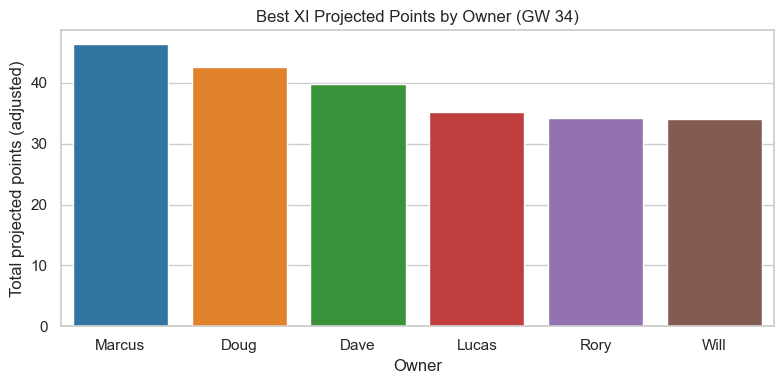

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=owner_summary,
    x='owner_name',
    y='predicted_points_adj_sum',
    hue='owner_name',
    legend=False,
    ax=ax,
    palette='tab10',
)
ax.set_title(f'Best XI Projected Points by Owner (GW {latest_gw})')
ax.set_xlabel('Owner')
ax.set_ylabel('Total projected points (adjusted)')
plt.xticks(rotation=0)
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'owner_best_xi_gw{latest_gw}.png', dpi=200)

## Shareable Plots

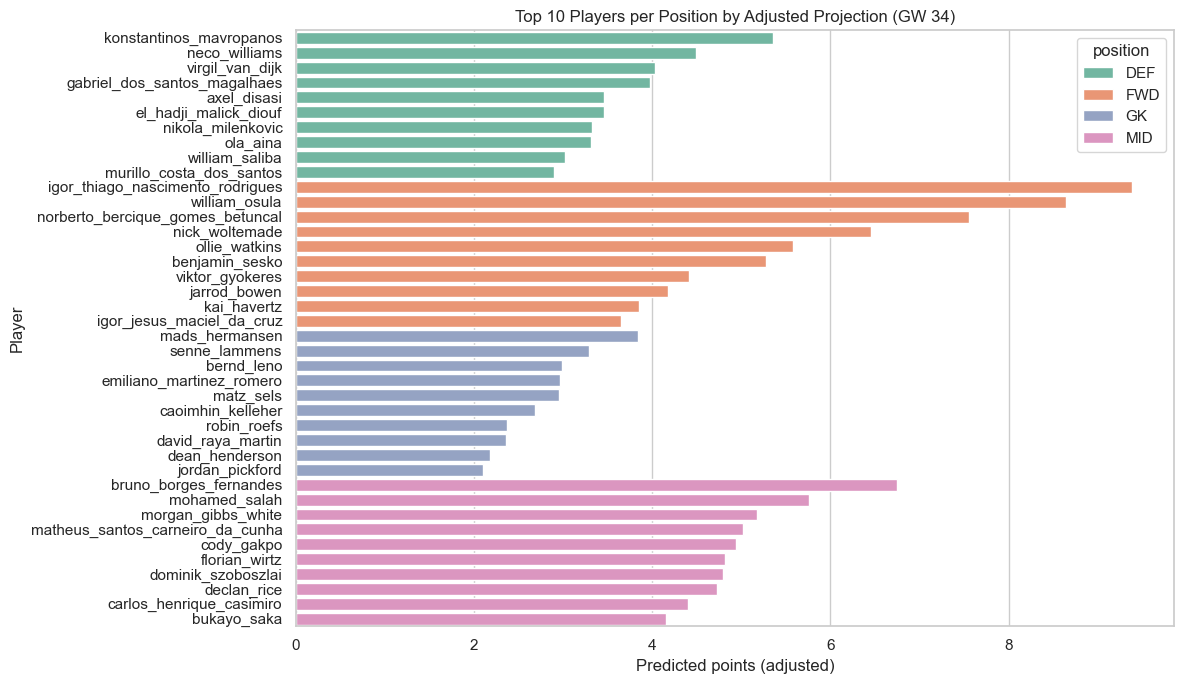

In [30]:
plot_df = (
    df_sorted
    .groupby('position', group_keys=False)
    .head(10)
    .copy()
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=plot_df.sort_values(['position', 'predicted_points_adj'], ascending=[True, False]),
    x='predicted_points_adj',
    y='full_name',
    hue='position',
    dodge=False,
    ax=ax,
    palette='Set2',
)
ax.set_title(f'Top 10 Players per Position by Adjusted Projection (GW {latest_gw})')
ax.set_xlabel('Predicted points (adjusted)')
ax.set_ylabel('Player')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'top10_by_position_gw{latest_gw}.png', dpi=200)

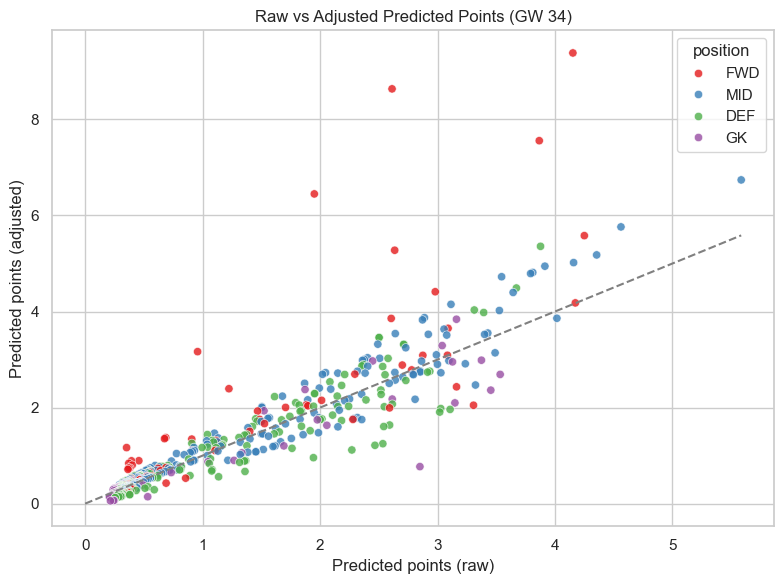

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=df_sorted,
    x='predicted_points',
    y='predicted_points_adj',
    hue='position',
    alpha=0.8,
    ax=ax,
    palette='Set1',
)
ax.plot([0, df_sorted['predicted_points'].max()], [0, df_sorted['predicted_points'].max()], linestyle='--', color='grey')
ax.set_title(f'Raw vs Adjusted Predicted Points (GW {latest_gw})')
ax.set_xlabel('Predicted points (raw)')
ax.set_ylabel('Predicted points (adjusted)')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'raw_vs_adjusted_gw{latest_gw}.png', dpi=200)

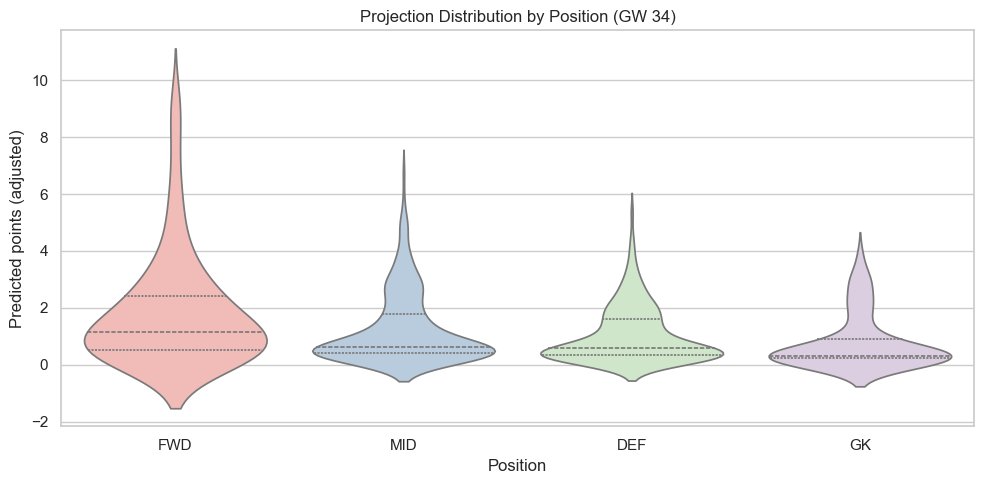

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(
    data=df_sorted,
    x='position',
    y='predicted_points_adj',
    inner='quartile',
    hue='position',
    legend=False,
    ax=ax,
    palette='Pastel1',
)
ax.set_title(f'Projection Distribution by Position (GW {latest_gw})')
ax.set_xlabel('Position')
ax.set_ylabel('Predicted points (adjusted)')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'distribution_by_position_gw{latest_gw}.png', dpi=200)

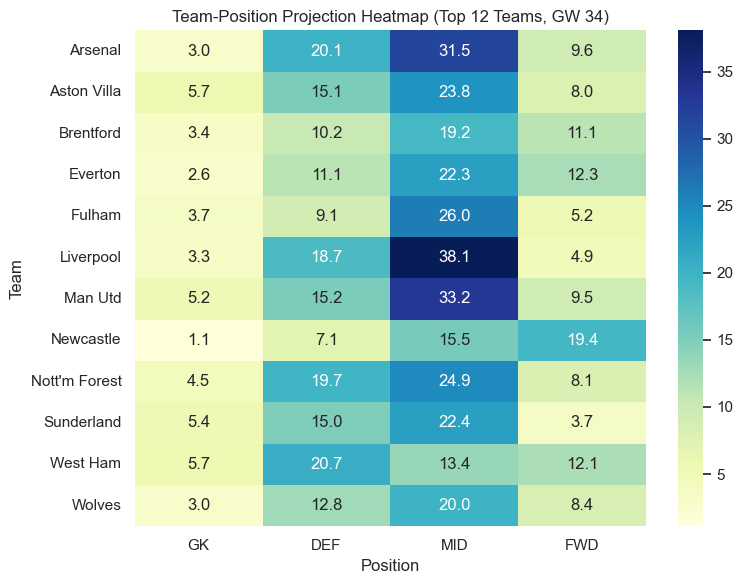

In [33]:
team_pos = (
    df_sorted
    .groupby(['team', 'position'], as_index=False)['predicted_points_adj']
    .sum()
)

team_total = team_pos.groupby('team', as_index=False)['predicted_points_adj'].sum()
top_teams = team_total.sort_values('predicted_points_adj', ascending=False).head(12)['team']
heat_df = team_pos[team_pos['team'].isin(top_teams)].pivot(index='team', columns='position', values='predicted_points_adj').fillna(0)
heat_df = heat_df[['GK', 'DEF', 'MID', 'FWD']]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heat_df, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax)
ax.set_title(f'Team-Position Projection Heatmap (Top 12 Teams, GW {latest_gw})')
ax.set_xlabel('Position')
ax.set_ylabel('Team')
plt.tight_layout()

if EXPORT_FIGURES:
    fig.savefig(FIG_DIR / f'team_position_heatmap_gw{latest_gw}.png', dpi=200)

In [34]:
share_cols = ['full_name', 'position', 'team', 'owner_name', 'predicted_points', 'predicted_points_adj', 'fixture_diff_index']
share_table = df_sorted[share_cols].head(25).copy()
share_table

,full_name,position,team,owner_name,predicted_points,predicted_points_adj,fixture_diff_index
0,igor_thiago_nascimento_rodrigues,FWD,Brentford,Marcus,4.152497,9.384306,2.259919
1,william_osula,FWD,Newcastle,Free Agent,2.612927,8.636394,3.305257
2,norberto_bercique_gomes_betuncal,FWD,Everton,Free Agent,3.866359,7.557248,1.954616
3,bruno_borges_fernandes,MID,Man Utd,Will,5.585495,6.740612,1.206806
4,nick_woltemade,FWD,Newcastle,Marcus,1.951174,6.449131,3.305257
5,mohamed_salah,MID,Liverpool,Marcus,4.561858,5.762311,1.263150
6,ollie_watkins,FWD,Aston Villa,Rory,4.250053,5.580240,1.312981
7,konstantinos_mavropanos,DEF,West Ham,Dave,3.877064,5.358010,1.381976
8,benjamin_sesko,FWD,Man Utd,Dave,2.635491,5.276377,2.002047
9,morgan_gibbs_white,MID,Nott'm Forest,Doug,4.355025,5.178737,1.189141


In [35]:
if EXPORT_FIGURES:
    print(f'Saved figures to: {FIG_DIR.resolve()}')
else:
    print('Set EXPORT_FIGURES = True to save PNG charts for sharing.')

Set EXPORT_FIGURES = True to save PNG charts for sharing.


## Historical Backtest: Predicted vs Actual (All GWs)

In [42]:
import re
import sys
import requests

sys.path.append(str(Path('..').resolve()))
from wrangle_data_funcs import clean_name

predictions_dir = Path('predictions')
pred_files = sorted(predictions_dir.glob('predicted_gw[0-9]*.csv'))

gw_file_pairs = []
for file_path in pred_files:
    if file_path.name.endswith('_simple.csv'):
        continue
    match = re.search(r'predicted_gw(\d+)\.csv$', file_path.name)
    if match:
        gw_file_pairs.append((int(match.group(1)), file_path))

gw_file_pairs = sorted(gw_file_pairs, key=lambda x: x[0])
print(f'Found GW prediction files: {len(gw_file_pairs)}')

bootstrap = requests.get('https://fantasy.premierleague.com/api/bootstrap-static/', timeout=20).json()
name_by_element = {}
for elem in bootstrap['elements']:
    full_name = clean_name(f"{elem['first_name']}_{elem['second_name']}")
    name_by_element[elem['id']] = full_name

def load_actual_points_for_gw_from_api(gw):
    event_live = requests.get(f'https://fantasy.premierleague.com/api/event/{gw}/live/', timeout=20).json()
    rows = []
    for item in event_live.get('elements', []):
        element_id = item.get('id')
        full_name = name_by_element.get(element_id)
        if full_name is None:
            continue
        total_points = item.get('stats', {}).get('total_points', np.nan)
        rows.append({'full_name': full_name, 'actual_points': total_points})

    actual_gw_df = pd.DataFrame(rows)
    if actual_gw_df.empty:
        raise ValueError(f'No actual rows returned from FPL API for GW {gw}')

    return actual_gw_df

backtest_frames = []
skipped_gws = []
for gw, file_path in gw_file_pairs:
    pred_gw_df = pd.read_csv(file_path)
    if 'predicted_points_adj' not in pred_gw_df.columns:
        pred_gw_df['predicted_points_adj'] = pred_gw_df['predicted_points']

    try:
        actual_gw_df = load_actual_points_for_gw_from_api(gw)
    except Exception as exc:
        skipped_gws.append((gw, str(exc)))
        continue

    merged = pred_gw_df.merge(actual_gw_df, on='full_name', how='inner')
    if merged.empty:
        skipped_gws.append((gw, 'No name overlap between prediction and actual files'))
        continue

    merged['gw'] = gw
    backtest_frames.append(
        merged[['gw', 'full_name', 'position', 'team', 'predicted_points', 'predicted_points_adj', 'actual_points']]
    )

backtest_df = pd.concat(backtest_frames, ignore_index=True) if backtest_frames else pd.DataFrame()
print(f'Total merged player-GW rows: {len(backtest_df):,}')
if skipped_gws:
    print(f'Skipped GWs: {[gw for gw, _ in skipped_gws]}')

if not backtest_df.empty:
    backtest_df['error_raw'] = backtest_df['predicted_points'] - backtest_df['actual_points']
    backtest_df['error_adj'] = backtest_df['predicted_points_adj'] - backtest_df['actual_points']
    backtest_df['abs_error_raw'] = backtest_df['error_raw'].abs()
    backtest_df['abs_error_adj'] = backtest_df['error_adj'].abs()

backtest_df.head()

Found GW prediction files: 33
Total merged player-GW rows: 25,083


,gw,full_name,position,team,predicted_points,predicted_points_adj,actual_points,error_raw,error_adj,abs_error_raw,abs_error_adj
0,2,aaron_anselmino,DEF,Chelsea,0.739413,6.059800,0,0.739413,6.059800,0.739413,6.059800
1,2,aaron_hickey,DEF,Brentford,0.729099,0.975531,1,-0.270901,-0.024469,0.270901,0.024469
2,2,aaron_ramsdale,GK,Newcastle,0.865016,2.491246,0,0.865016,2.491246,0.865016,2.491246
3,2,aaron_ramsey,MID,Burnley,0.665792,0.547374,0,0.665792,0.547374,0.665792,0.547374
4,2,aaron_wan_bissaka,DEF,West Ham,2.558778,1.878468,0,2.558778,1.878468,2.558778,1.878468


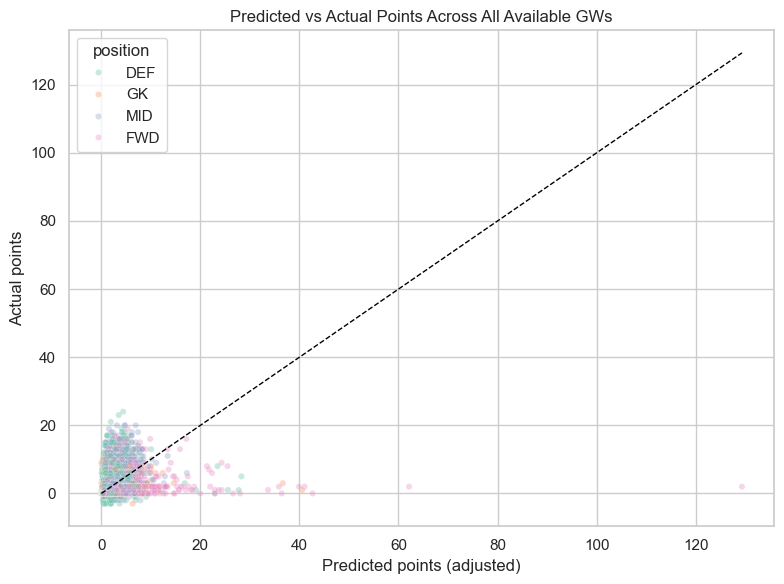

In [43]:
if backtest_df.empty:
    print('No backtest rows available. Check BACKTEST_YEAR and prediction files.')
else:
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(
        data=backtest_df,
        x='predicted_points_adj',
        y='actual_points',
        hue='position',
        alpha=0.35,
        s=20,
        ax=ax,
        palette='Set2',
    )

    max_axis = max(backtest_df['predicted_points_adj'].max(), backtest_df['actual_points'].max(), 1)
    ax.plot([0, max_axis], [0, max_axis], linestyle='--', color='black', linewidth=1)
    ax.set_title(f'Predicted vs Actual Points Across All Available GWs')
    ax.set_xlabel('Predicted points (adjusted)')
    ax.set_ylabel('Actual points')
    plt.tight_layout()

    if EXPORT_FIGURES:
        fig.savefig(FIG_DIR / 'pred_vs_actual_all_gws.png', dpi=200)

,gw,mae_raw,mae_adj,rmse_raw,rmse_adj,corr_adj,n_players
0,2,1.398942,3.031277,2.290521,7.130428,0.128786,688
1,3,1.367993,1.751509,2.044060,3.369252,0.237116,704
2,4,1.374622,1.598399,2.056003,2.816350,0.386894,711
3,5,1.274219,1.544102,1.905574,2.917723,0.316065,739
4,6,1.233781,1.430650,1.938378,2.333200,0.442224,740
5,7,1.288138,1.448172,1.965947,2.374257,0.428807,741
6,8,1.335244,1.444678,2.145013,2.361295,0.472751,742
7,9,1.294102,1.432641,2.076107,3.082161,0.299649,744
8,10,1.300248,1.452354,1.942554,2.234027,0.480215,745
9,11,1.348842,1.476944,2.078492,2.306451,0.465562,746


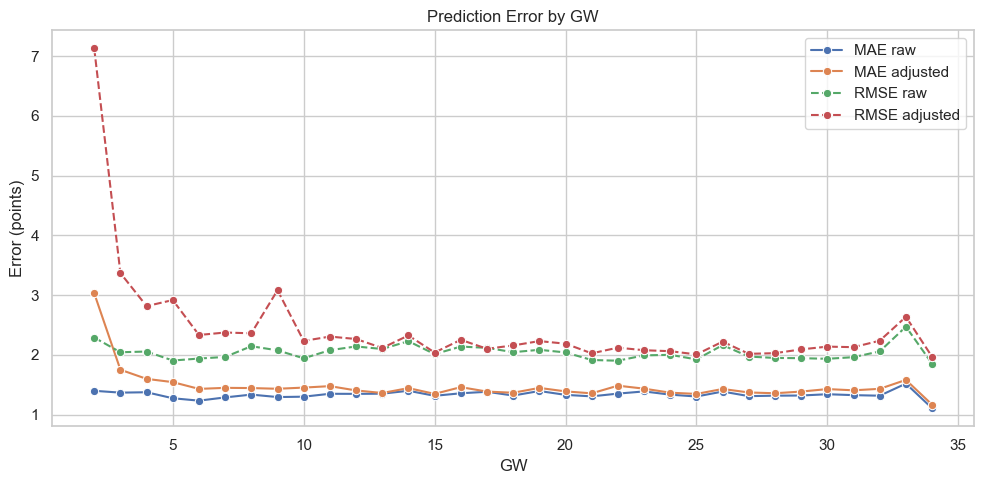

In [44]:
if backtest_df.empty:
    print('No backtest rows available. Skipping GW metric plots.')
else:
    gw_metrics = (
        backtest_df.groupby('gw', as_index=False)
        .agg(
            mae_raw=('abs_error_raw', 'mean'),
            mae_adj=('abs_error_adj', 'mean'),
            rmse_raw=('error_raw', lambda x: np.sqrt(np.mean(np.square(x)))),
            rmse_adj=('error_adj', lambda x: np.sqrt(np.mean(np.square(x)))),
            corr_adj=('predicted_points_adj', lambda x: x.corr(backtest_df.loc[x.index, 'actual_points'])),
            n_players=('full_name', 'count'),
        )
    )

    display(gw_metrics)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.lineplot(data=gw_metrics, x='gw', y='mae_raw', marker='o', label='MAE raw', ax=ax)
    sns.lineplot(data=gw_metrics, x='gw', y='mae_adj', marker='o', label='MAE adjusted', ax=ax)
    sns.lineplot(data=gw_metrics, x='gw', y='rmse_raw', marker='o', label='RMSE raw', ax=ax, linestyle='--')
    sns.lineplot(data=gw_metrics, x='gw', y='rmse_adj', marker='o', label='RMSE adjusted', ax=ax, linestyle='--')
    ax.set_title('Prediction Error by GW')
    ax.set_xlabel('GW')
    ax.set_ylabel('Error (points)')
    plt.tight_layout()

    if EXPORT_FIGURES:
        fig.savefig(FIG_DIR / 'prediction_error_by_gw.png', dpi=200)

### What Is corr_adj?

`corr_adj` is the Pearson correlation between `predicted_points_adj` and `actual_points` within each GW.

- `corr_adj` near `1.0`: your model ranked players very well that week.
- `corr_adj` near `0.0`: weak relationship between predictions and outcomes.
- `corr_adj` below `0.0`: rankings were directionally wrong that week.

This is most useful for judging ranking quality, not absolute error size.

,gw,corr_adj
0,2,0.128786
1,3,0.237116
2,4,0.386894
3,5,0.316065
4,6,0.442224
5,7,0.428807
6,8,0.472751
7,9,0.299649
8,10,0.480215
9,11,0.465562


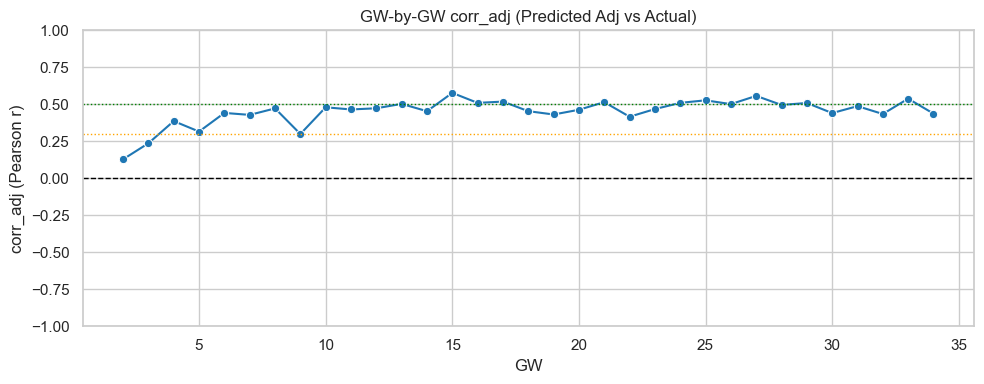

In [45]:
if backtest_df.empty:
    print('No backtest rows available. Skipping corr_adj plot.')
else:
    corr_plot_df = gw_metrics[['gw', 'corr_adj']].dropna().copy()

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.lineplot(data=corr_plot_df, x='gw', y='corr_adj', marker='o', ax=ax, color='#1f77b4')
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.axhline(0.5, color='green', linestyle=':', linewidth=1)
    ax.axhline(0.3, color='orange', linestyle=':', linewidth=1)
    ax.set_ylim(-1, 1)
    ax.set_title('GW-by-GW corr_adj (Predicted Adj vs Actual)')
    ax.set_xlabel('GW')
    ax.set_ylabel('corr_adj (Pearson r)')
    plt.tight_layout()

    display(corr_plot_df)

    if EXPORT_FIGURES:
        fig.savefig(FIG_DIR / 'corr_adj_by_gw.png', dpi=200)